### Customer Churn Prediction

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("../data/raw/data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Data Understanding


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Check Target Variable


In [8]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

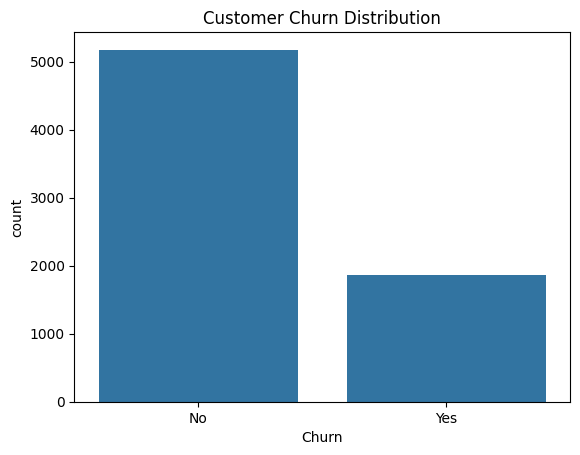

In [9]:
sns.countplot(x=df["Churn"])

plt.title("Customer Churn Distribution")
plt.show()

Most customers are retained, while fewer customers churn.
This indicates slight class imbalance.

### Data cleaning


In [10]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
df["TotalCharges"].dtype

dtype('float64')

In [11]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Now total charges have some missing values

In [12]:
df.dropna(inplace=True)

### Customer Tenure Analysis

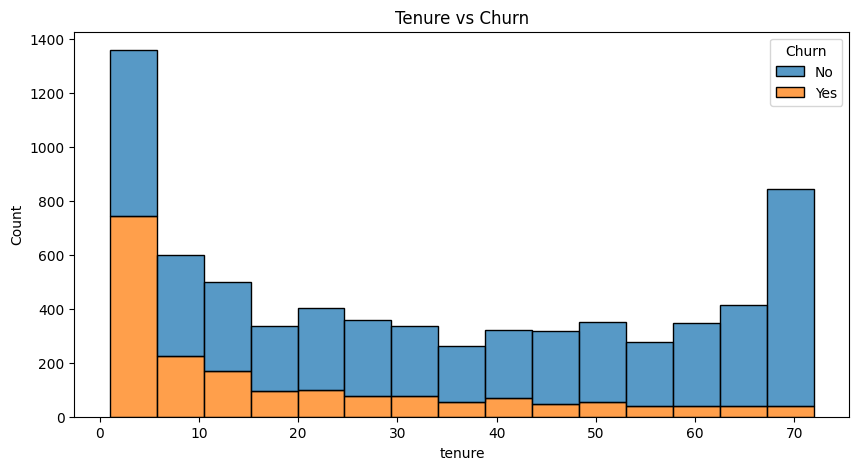

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    multiple="stack"
)

plt.title("Tenure vs Churn")
plt.show()

Customers with lower tenure tend to churn more frequently.

### Monthly Charge Analysis

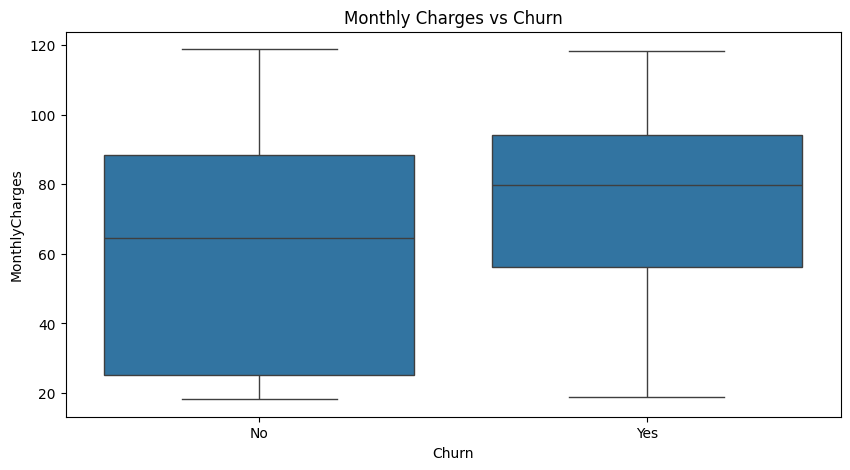

In [14]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["Churn"],
    y=df["MonthlyCharges"]
)

plt.title("Monthly Charges vs Churn")
plt.show()

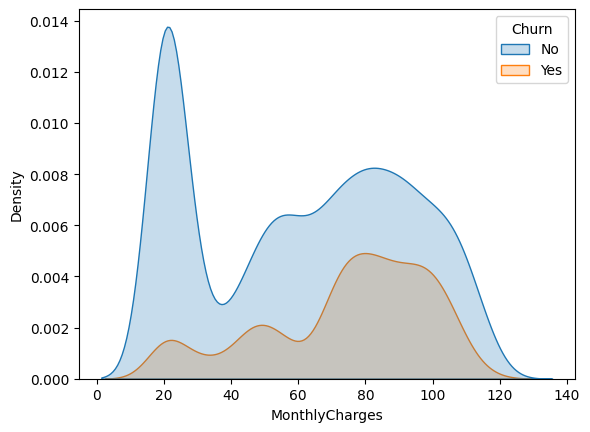

In [20]:
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True)
plt.show()

Customers with higher monthly charges appear more likely to churn.

### Contract Type Analysis

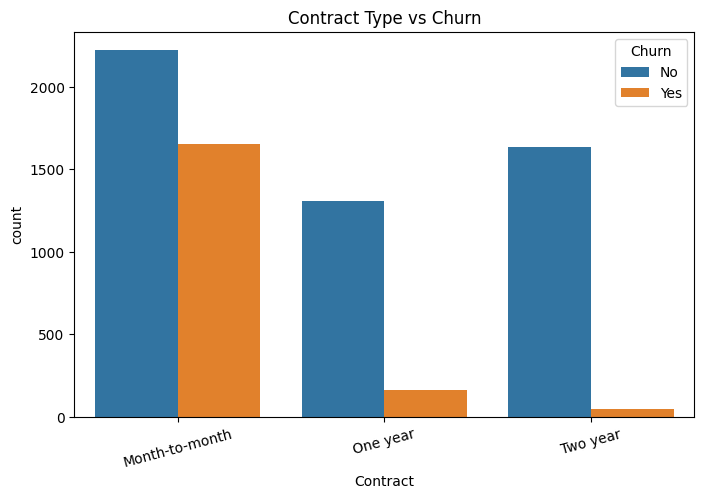

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()

Month-to-month contracts show significantly higher churn rates.

### Payment Method Analysis

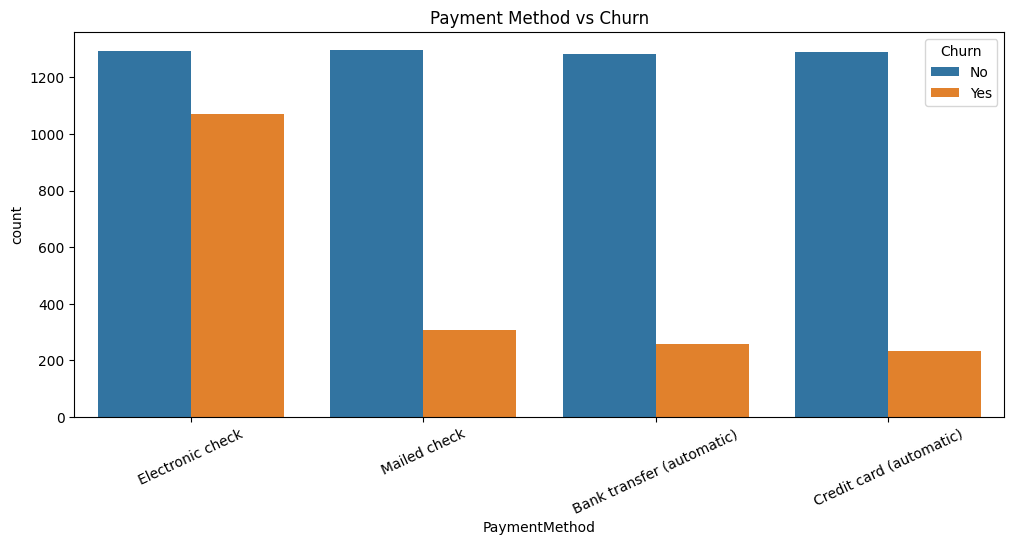

In [17]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.xticks(rotation=25)
plt.title("Payment Method vs Churn")

plt.show()

### Correlation Heatmap

/var/folders/n6/kczf4rrj169997qby_6wvd3r0000gn/T/ipykernel_63134/3362820412.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in temp_df.select_dtypes(include="object").columns:


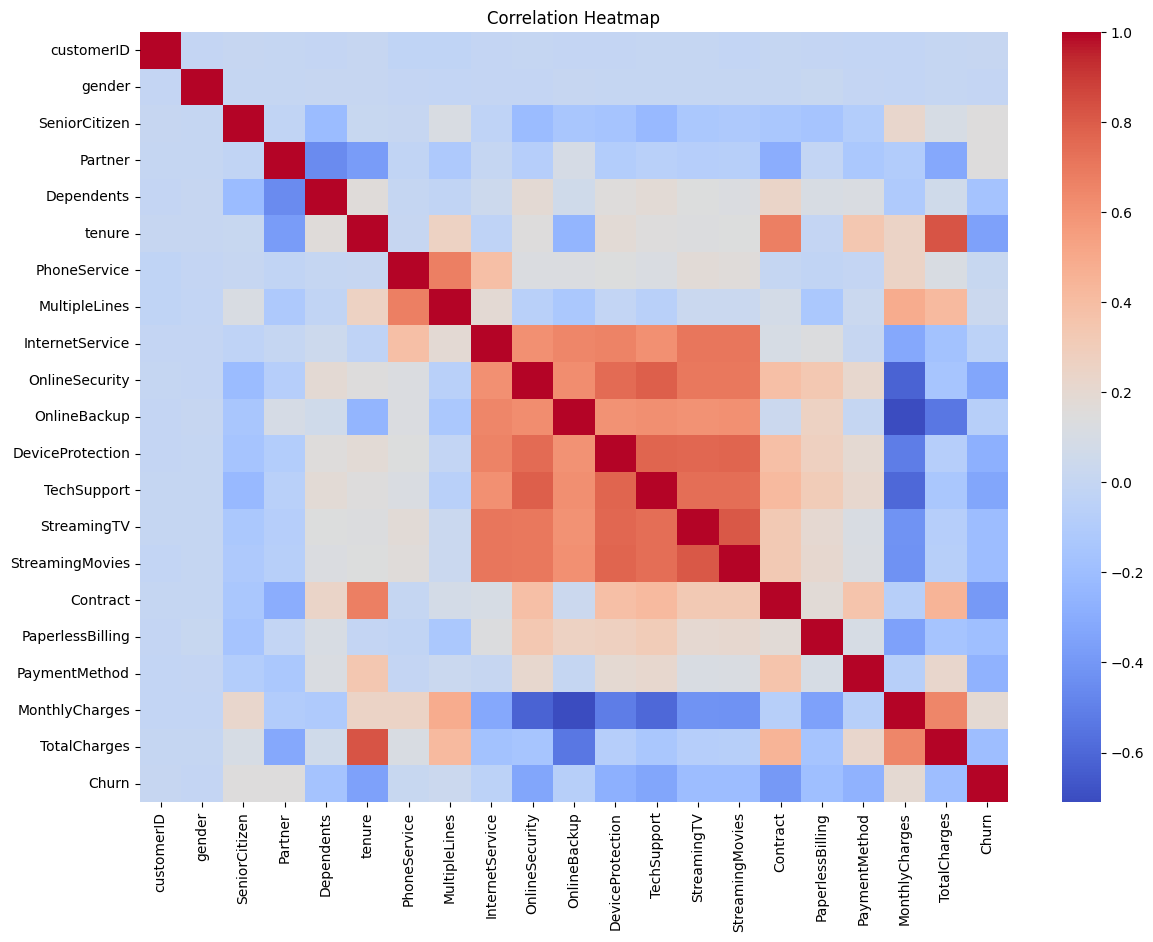

In [18]:
temp_df = df.copy()

for col in temp_df.select_dtypes(include="object").columns:
    temp_df[col], _ = pd.factorize(temp_df[col])

plt.figure(figsize=(14,10))

sns.heatmap(
    temp_df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Save Cleaned Data

In [19]:
df.to_csv(
    "../data/processed/cleaned.csv",
    index=False
)